- You freeze Tessera (don't fine-tune it) → it outputs embeddings
- You train a lightweight classifier (e.g., logistic regression, MLP) on top of those embeddings using labels from year A only
- You then test that classifier on embeddings from year B, C...


- **The question**: does the Tessera embedding space generalize across years, or does the shift break the classifier?

------------

**Train year**:  2020 labels + 2020 embeddings → fit classifier (e.g., logistic regression)

**Test years**:  apply same frozen classifier to 2021, 2022, 2023 embeddings

**Measure**:     accuracy / F1 / kappa per year → plot degradation curve

_______

| Metric                                      | What it tells you                                                                 |
|---------------------------------------------|----------------------------------------------------------------------------------|
| Maximum Mean Discrepancy (MMD)              | Distance between distributions in a kernel space; scalar per feature or global  |
| Fréchet Distance (on PCA-reduced features)  | Like FID for images; compares mean + covariance                                 |
| Per-band KL divergence / Wasserstein distance | Per-channel shift, useful to see which bands/indices drift most                |
| PCA/UMAP visualization                      | Visual confirmation — do year clouds overlap or separate?                        |

For each source (raw_S1, raw_S2, tessera_embeddings):
  1. Compute pairwise MMD between all year pairs → heatmap
  2. UMAP colored by year → visual shift
  3. Train classifier on year_A only
     - evaluate on year_A (in-domain), year_B, year_C... (out-of-domain)
     - record Δ accuracy = acc(in-domain) - acc(out-of-domain)
  4. Compare Δ across sources

# import libraries

In [83]:
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, cohen_kappa_score, confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.metrics import silhouette_samples, silhouette_score

/Users/devseed/Documents/docs/THESIS/SpatialTemporal_generalization_of_SITS_FM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# define variables

In [90]:
S1_BANDS = ['VV', 'VH']
S2_BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
  
TRAIN_YEARS = [2018]  
TEST_YEARS  = [2019, 2020, 2021, 2022, 2023] 

EMBEDDINGS_DIR = Path('_data/exports/embeddings_exports')
RAW_DATA_DIR = Path('_data/exports/image_points_exports')

# read datasets

In [91]:
def load_raw_datasets(data_dir, country_filter='fr'):
    data_dir = Path(data_dir)
    datasets = {}

    for filepath in sorted(data_dir.glob('*.pkl')):
        stem  = filepath.stem
        parts = stem.rsplit('_', 3)

        if len(parts) != 4 or parts[3] != 'image':
            print(f"Skipping {filepath.name} — unexpected filename format")
            continue

        crop, country, year = parts[0], parts[1], int(parts[2])

        if country != country_filter:
            continue

        with open(filepath, 'rb') as f:
            data = pickle.load(f)

        datasets[f"{crop}_{country}_{year}"] = data
        print(f"Loaded {filepath.name} → country={country} | crop={crop} | year={year} | {len(data)} samples")

    print(f"\nTotal datasets loaded: {len(datasets)}")
    return datasets

In [92]:
def load_embedding_datasets(data_dir, country_filter='fr'):
    data_dir = Path(data_dir)
    datasets = {}

    for filepath in sorted(data_dir.glob('*.parquet')):
        stem  = filepath.stem
        parts = stem.rsplit('_', 3)

        if len(parts) != 4 or parts[3] != 'embedding':
            print(f"Skipping {filepath.name} — unexpected filename format")
            continue

        crop, country, year = parts[0], parts[1], int(parts[2])

        if country != country_filter:
            continue

        df = pd.read_parquet(filepath)
        df['crop']    = crop
        df['country'] = country
        df['year']    = year

        datasets[f"{crop}_{country}_{year}"] = df
        print(f"Loaded {filepath.name} → country={country} | crop={crop} | year={year} | {len(df)} samples")

    print(f"\nTotal datasets loaded: {len(datasets)}")
    return datasets

In [93]:
raw_data = load_raw_datasets(RAW_DATA_DIR)

Loaded maize_corn_popcorn_fr_2018_image.pkl → country=fr | crop=maize_corn_popcorn | year=2018 | 500 samples
Loaded maize_corn_popcorn_fr_2019_image.pkl → country=fr | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_fr_2020_image.pkl → country=fr | crop=maize_corn_popcorn | year=2020 | 500 samples
Loaded maize_corn_popcorn_fr_2021_image.pkl → country=fr | crop=maize_corn_popcorn | year=2021 | 500 samples
Loaded maize_corn_popcorn_fr_2022_image.pkl → country=fr | crop=maize_corn_popcorn | year=2022 | 500 samples
Loaded potatoes_fr_2018_image.pkl → country=fr | crop=potatoes | year=2018 | 500 samples
Loaded potatoes_fr_2019_image.pkl → country=fr | crop=potatoes | year=2019 | 500 samples
Loaded potatoes_fr_2020_image.pkl → country=fr | crop=potatoes | year=2020 | 500 samples
Loaded potatoes_fr_2021_image.pkl → country=fr | crop=potatoes | year=2021 | 500 samples
Loaded potatoes_fr_2022_image.pkl → country=fr | crop=potatoes | year=2022 | 500 samples
Loaded win

In [136]:
embedding_data = load_embedding_datasets(EMBEDDINGS_DIR)

Loaded maize_corn_popcorn_fr_2018_embedding.parquet → country=fr | crop=maize_corn_popcorn | year=2018 | 500 samples
Loaded maize_corn_popcorn_fr_2019_embedding.parquet → country=fr | crop=maize_corn_popcorn | year=2019 | 500 samples
Loaded maize_corn_popcorn_fr_2020_embedding.parquet → country=fr | crop=maize_corn_popcorn | year=2020 | 500 samples
Loaded maize_corn_popcorn_fr_2021_embedding.parquet → country=fr | crop=maize_corn_popcorn | year=2021 | 500 samples
Loaded maize_corn_popcorn_fr_2022_embedding.parquet → country=fr | crop=maize_corn_popcorn | year=2022 | 500 samples
Loaded maize_corn_popcorn_fr_2023_embedding.parquet → country=fr | crop=maize_corn_popcorn | year=2023 | 500 samples
Loaded potatoes_fr_2018_embedding.parquet → country=fr | crop=potatoes | year=2018 | 500 samples
Loaded potatoes_fr_2019_embedding.parquet → country=fr | crop=potatoes | year=2019 | 500 samples
Loaded potatoes_fr_2020_embedding.parquet → country=fr | crop=potatoes | year=2020 | 500 samples
Loaded 

# classifiers

In [95]:
models = {'LogisticRegression': Pipeline([('scaler', StandardScaler()), 
                                          ('clf', LogisticRegression(max_iter=1000, random_state=42))]), 
          'RandomForest': Pipeline([('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))])}


def evaluate_model(name, pipeline, x_train, y_train, x_test, y_test):
    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)
    print(f"--{name}--")
    print(classification_report(y_test, y_pred))

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    kappa = cohen_kappa_score(y_test, y_pred)
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    return pipeline, accuracy , f1, kappa, y_pred

# raw data

## compute indices

In [96]:
def compute_s1_indices(s1):
    s1  = s1.copy()
    eps = 1e-8
    s1['VV_VH_ratio'] = s1['VV'] / (s1['VH'] + eps)
    s1['RVI']         = 4 * s1['VH'] / (s1['VV'] + s1['VH'] + eps)
    return s1

In [97]:
def compute_s2_indices(s2):
    s2  = s2.copy()
    eps = 1e-8
    s2['NDVI'] = (s2['B8']  - s2['B4']) / (s2['B8']  + s2['B4'] + eps)
    s2['NDWI'] = (s2['B3']  - s2['B8']) / (s2['B3']  + s2['B8'] + eps)
    s2['NDRE'] = (s2['B8']  - s2['B5']) / (s2['B8']  + s2['B5'] + eps)
    s2['EVI']  = 2.5 * (s2['B8'] - s2['B4']) / (s2['B8'] + 6*s2['B4'] - 7.5*s2['B2'] + 1 + eps)
    return s2

In [98]:
raw_data['potatoes_fr_2019'][0]['s1'].head(2)

,longitude,latitude,VV,VH,date
0,-0.702258,45.638144,-8.429082,-17.433812,2019-01-01 06:08:09
1,-0.702258,45.638144,-8.367818,-17.801057,2019-01-01 06:08:18


In [99]:
raw_data['potatoes_fr_2019'][0]['s2'].head(2)

,longitude,latitude,B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12,date
0,-0.702258,45.638144,419,697,1040,1260,1406,1493,1610,1634,2209,1852,2019-01-04 11:08:31
1,-0.702258,45.638144,656,933,1094,1428,1630,1719,1984,1876,1984,1525,2019-01-09 11:08:28


In [100]:
for key in raw_data.keys():
    country_year = raw_data[key]
    for i in range(len(country_year)):
        s1 = country_year[i]['s1']
        s2 = country_year[i]['s2']
        raw_data[key][i]['s1'] = compute_s1_indices(s1)
        raw_data[key][i]['s2'] = compute_s2_indices(s2)

In [101]:
raw_data['potatoes_fr_2019'][0]['s1'].head(2)

,longitude,latitude,VV,VH,date,VV_VH_ratio,RVI
0,-0.702258,45.638144,-8.429082,-17.433812,2019-01-01 06:08:09,0.483490,2.696344
1,-0.702258,45.638144,-8.367818,-17.801057,2019-01-01 06:08:18,0.470074,2.720951


In [102]:
raw_data['potatoes_fr_2019'][0]['s2'].head(2)

,longitude,latitude,B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12,date,NDVI,NDWI,NDRE,EVI
0,-0.702258,45.638144,419,697,1040,1260,1406,1493,1610,1634,2209,1852,2019-01-04 11:08:31,0.215094,-0.395752,0.121951,0.302644
1,-0.702258,45.638144,656,933,1094,1428,1630,1719,1984,1876,1984,1525,2019-01-09 11:08:28,0.289149,-0.360302,0.162954,0.613117


## agregate data and feature engineering

In [103]:
def aggregate_monthly_s1(df):
    feat_df = df[['VV', 'VH', 'VV_VH_ratio', 'RVI']].copy()
    feat_df['month'] = pd.to_datetime(df['date']).dt.month
    
    agg = feat_df.groupby('month').agg(['mean', 'std'])
    agg = agg.reindex(range(1, 13))
    agg.columns = ['_'.join(map(str, c)) for c in agg.columns]
    row = agg.unstack()
    row.index = ['_'.join(map(str, i)) for i in row.index]
    return row

In [104]:
def aggregate_monthly_s2(df):
    s2_bands   = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12']
    s2_indices = ['NDVI','NDWI','NDRE','EVI']
    
    feat_df = df[s2_bands + s2_indices].copy()
    feat_df['month'] = pd.to_datetime(df['date']).dt.month
    
    agg = feat_df.groupby('month').agg(['mean', 'std'])
    agg = agg.reindex(range(1, 13))
    agg.columns = ['_'.join(map(str, c)) for c in agg.columns]
    row = agg.unstack()
    row.index = ['_'.join(map(str, i)) for i in row.index]
    return row

In [105]:
def fit_harmonics(df, feature):
    doy = pd.to_datetime(df['date']).dt.dayofyear.values
    values = df[feature].values
    
    t = 2 * np.pi * doy / 365
    X = np.column_stack([
        np.ones_like(t),
        np.cos(t), np.sin(t),      # annual cycle
        np.cos(2*t), np.sin(2*t)   # semi annual cycle
    ])
    
    coeffs, _, _, _ = np.linalg.lstsq(X, values, rcond=None)
    
    offset      = coeffs[0]
    amplitude_1 = np.sqrt(coeffs[1]**2 + coeffs[2]**2)
    phase_1     = np.arctan2(coeffs[2], coeffs[1])
    amplitude_2 = np.sqrt(coeffs[3]**2 + coeffs[4]**2)
    phase_2     = np.arctan2(coeffs[4], coeffs[3])
    
    return offset, amplitude_1, phase_1, amplitude_2, phase_2

In [106]:
def extract_harmonic_features(s1_df, s2_df):
    features = {}
    
    for feat in ['NDVI', 'EVI', 'NDRE', 'NDWI']:
        o, a1, p1, a2, p2 = fit_harmonics(s2_df, feat)
        features[f'{feat}_offset']      = o
        features[f'{feat}_amplitude_1'] = a1
        features[f'{feat}_phase_1']     = p1
        features[f'{feat}_amplitude_2'] = a2
        features[f'{feat}_phase_2']     = p2
    
    for feat in ['VV', 'VH', 'RVI']:
        o, a1, p1, a2, p2 = fit_harmonics(s1_df, feat)
        features[f'{feat}_offset']      = o
        features[f'{feat}_amplitude_1'] = a1
        features[f'{feat}_phase_1']     = p1
        features[f'{feat}_amplitude_2'] = a2
        features[f'{feat}_phase_2']     = p2
    
    return pd.Series(features)

In [107]:
rows = []

for key, points_list in raw_data.items():
    parts = key.split("_")
    label = "_".join(parts[:-2])
    country = parts[-2]
    
    for point in points_list:
        row_s1 = aggregate_monthly_s1(point['s1'])
        row_s2 = aggregate_monthly_s2(point['s2'])
        # harmonic_row = extract_harmonic_features(point['s1'], point['s2'])
        
        lat = point['point_coord'][1]
        lon = point['point_coord'][0]
        
        # combined_row = pd.concat([row_s1, row_s2, harmonic_row])
        combined_row = pd.concat([row_s1, row_s2])
        combined_row['latitude']  = lat
        combined_row['longitude'] = lon
        combined_row['country'] = country
        combined_row['crop'] = label
        combined_row['year'] = int(parts[-1])
        
        rows.append(combined_row)

raw_df = pd.DataFrame(rows).reset_index(drop=True)

In [108]:
raw_df.head(2)

,VV_mean_1,VV_mean_2,VV_mean_3,VV_mean_4,VV_mean_5,VV_mean_6,VV_mean_7,VV_mean_8,VV_mean_9,VV_mean_10,...,EVI_std_8,EVI_std_9,EVI_std_10,EVI_std_11,EVI_std_12,latitude,longitude,country,crop,year
0,-10.405292,-11.549323,-9.323263,-8.985673,-11.531740,-11.957869,-11.783597,-10.665956,-10.591316,-11.900688,...,2.576991,5.804851,0.387756,2.261456,0.838284,49.710431,1.673617,fr,maize_corn_popcorn,2018
1,-5.548731,-7.222789,-4.779294,-8.902714,-13.245321,-11.990806,-10.259269,-9.543221,-11.537071,-11.072231,...,1.135065,0.742619,4.084302,0.450386,0.538309,49.053924,1.000040,fr,maize_corn_popcorn,2018


In [109]:
print(f"Shape of raw df: {raw_df.shape}")
print(f"Crops on raw df: {raw_df['crop'].unique()}")
print(f"Years on raw df: {raw_df['year'].unique()}")
print(f"Country on raw df: {raw_df['country'].unique()}")

Shape of raw df: (7500, 437)
Crops on raw df: ['maize_corn_popcorn' 'potatoes' 'winter_barley']
Years on raw df: [2018 2019 2020 2021 2022]
Country on raw df: ['fr']


## split train test

In [110]:
raw_train_df = raw_df[raw_df['year'].isin(TRAIN_YEARS)].reset_index(drop=True)
raw_test_df  = raw_df[raw_df['year'].isin(TEST_YEARS)].reset_index(drop=True)

In [111]:
print(f"Years on raw train df: {raw_train_df['year'].unique()}")
print(f"Years on raw test df: {raw_test_df['year'].unique()}")

Years on raw train df: [2018]
Years on raw test df: [2019 2020 2021 2022]


In [113]:
raw_train_df.head(2)

,VV_mean_1,VV_mean_2,VV_mean_3,VV_mean_4,VV_mean_5,VV_mean_6,VV_mean_7,VV_mean_8,VV_mean_9,VV_mean_10,...,EVI_std_8,EVI_std_9,EVI_std_10,EVI_std_11,EVI_std_12,latitude,longitude,country,crop,year
0,-10.405292,-11.549323,-9.323263,-8.985673,-11.531740,-11.957869,-11.783597,-10.665956,-10.591316,-11.900688,...,2.576991,5.804851,0.387756,2.261456,0.838284,49.710431,1.673617,fr,maize_corn_popcorn,2018
1,-5.548731,-7.222789,-4.779294,-8.902714,-13.245321,-11.990806,-10.259269,-9.543221,-11.537071,-11.072231,...,1.135065,0.742619,4.084302,0.450386,0.538309,49.053924,1.000040,fr,maize_corn_popcorn,2018


In [114]:
raw_test_df.head(2)

,VV_mean_1,VV_mean_2,VV_mean_3,VV_mean_4,VV_mean_5,VV_mean_6,VV_mean_7,VV_mean_8,VV_mean_9,VV_mean_10,...,EVI_std_8,EVI_std_9,EVI_std_10,EVI_std_11,EVI_std_12,latitude,longitude,country,crop,year
0,-9.450818,-9.679897,-8.457569,-12.199396,-12.836148,-10.290837,-13.011849,-12.877887,-12.018335,-9.694064,...,45.258561,5.332017,1.326574,0.605264,0.691726,45.382295,-0.039093,fr,maize_corn_popcorn,2019
1,-12.228727,-12.194968,-7.725038,-11.963764,-12.249956,-10.874045,-13.743694,-12.987441,-11.879744,-10.916690,...,9.344353,1.209208,2.277513,0.345552,0.394610,45.378329,-0.053827,fr,maize_corn_popcorn,2019


In [121]:
# drop columns
drop_cols = ['latitude', 'longitude', 'crop', 'country', 'year']

print(f"Train shape for raw: {raw_train_df.shape}")
print(f"Test shape for raw: {raw_test_df.shape}")

raw_x_train = raw_train_df.drop(columns=drop_cols)
raw_y_train = raw_train_df['crop']

raw_x_test  = raw_test_df.drop(columns=drop_cols)
raw_y_test  = raw_test_df['crop']

print(f"Train shape for raw: {raw_x_train.shape}")
print(f"Test shape for raw: {raw_x_test.shape}")

Train shape for raw: (1500, 437)
Test shape for raw: (6000, 437)
Train shape for raw: (1500, 432)
Test shape for raw: (6000, 432)


In [122]:
# check Nan values
print(f"Nan values before for raw_x_train: {raw_x_train.isnull().sum().sum()}")  
print(f"Nan values before for raw_x_text: {raw_x_test.isnull().sum().sum()}")   

raw_x_train = raw_x_train.ffill(axis=0).bfill(axis=0).fillna(raw_x_train.mean())
raw_x_test  = raw_x_test.ffill(axis=0).bfill(axis=0).fillna(raw_x_train.mean()) 

print(f"Nan values after for raw_x_train: {raw_x_train.isnull().sum().sum()}")  
print(f"Nan values after for raw_x_text: {raw_x_test.isnull().sum().sum()}") 

Nan values before for raw_x_train: 0
Nan values before for raw_x_text: 0
Nan values after for raw_x_train: 0
Nan values after for raw_x_text: 0


## appy models

--LogisticRegression--
                    precision    recall  f1-score   support

maize_corn_popcorn       0.80      0.84      0.82      2000
          potatoes       0.84      0.70      0.76      2000
     winter_barley       0.84      0.95      0.90      2000

          accuracy                           0.83      6000
         macro avg       0.83      0.83      0.83      6000
      weighted avg       0.83      0.83      0.83      6000



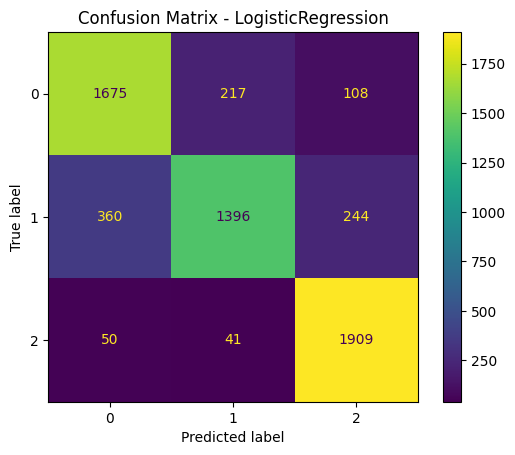

In [123]:
# logistic regression
lr_raw, lr_raw_accuracy, lr_raw_f1, lr_raw_kappa, lr_raw_y_pred = evaluate_model('LogisticRegression', 
                        models['LogisticRegression'], 
                        raw_x_train, raw_y_train, raw_x_test, raw_y_test)

--RandomForest--
                    precision    recall  f1-score   support

maize_corn_popcorn       0.92      0.77      0.84      2000
          potatoes       0.79      0.89      0.83      2000
     winter_barley       0.93      0.97      0.95      2000

          accuracy                           0.87      6000
         macro avg       0.88      0.87      0.87      6000
      weighted avg       0.88      0.87      0.87      6000



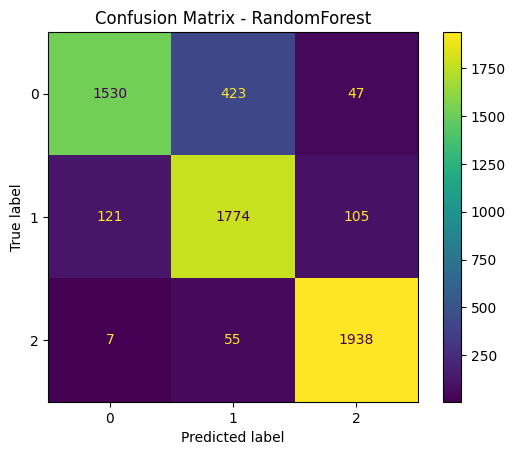

In [124]:
# random forest
rf_raw, rf_raw_accuracy, rf_raw_f1, rf_raw_kappa, rf_raw_y_pred = evaluate_model('RandomForest', 
                        models['RandomForest'], 
                        raw_x_train, raw_y_train, raw_x_test, raw_y_test)

# embeddings data

## pre processing

In [137]:
embeddings_df = pd.concat(embedding_data.values(), ignore_index=True)

print(f"Original embeddings shape: {embeddings_df.shape}")
print(f"Embedding length: {len(embeddings_df['embedding'].iloc[0])}") 
print(f"Crops on embedding df: {embeddings_df['crop'].unique()}")
print(f"Years on embedding df: {embeddings_df['year'].unique()}")
print(f"Country on embedding df: {embeddings_df['country'].unique()}")

Original embeddings shape: (9000, 12)
Embedding length: 128
Crops on embedding df: ['maize_corn_popcorn' 'potatoes' 'winter_barley']
Years on embedding df: [2018 2019 2020 2021 2022 2023]
Country on embedding df: ['fr']


In [138]:
embeddings_df.head(2)

,tile_lon,tile_lat,pixel_row,pixel_col,crs,embedding,long_lat,crop,country_id,year,country,error
0,1.65,49.75,1005.0,532.0,EPSG:32631,"[2.3069363, -0.3938672, 0.7877344, 2.6445367, ...","[1.6736168980811237, 49.710431244293936]",maize_corn_popcorn,fr,2018,fr,NaN
1,1.05,49.05,512.0,16.0,EPSG:32631,"[4.9744644, 0.32442158, 1.027335, 2.865724, 2....","[1.0000396743907862, 49.05392391283792]",maize_corn_popcorn,fr,2018,fr,NaN


In [139]:
# drop whats no necessary
embeddings_df = embeddings_df.drop(columns=['tile_lon', 'tile_lat', 'pixel_row', 'pixel_col', 'crs', 'country_id', 'error'])
embeddings_df = embeddings_df[embeddings_df['country'] != 'pt'].reset_index(drop=True)
print(f"Processed embeddings shape: {embeddings_df.shape}")
print(f"Embedding length: {len(embeddings_df['embedding'].iloc[0])}") 
print(f"Crops on embedding df: {embeddings_df['crop'].unique()}")
print(f"Years on embedding df: {embeddings_df['year'].unique()}")
print(f"Country on embedding df: {embeddings_df['country'].unique()}")

Processed embeddings shape: (9000, 5)
Embedding length: 128
Crops on embedding df: ['maize_corn_popcorn' 'potatoes' 'winter_barley']
Years on embedding df: [2018 2019 2020 2021 2022 2023]
Country on embedding df: ['fr']


In [140]:
embeddings_df.head(2)

,embedding,long_lat,crop,year,country
0,"[2.3069363, -0.3938672, 0.7877344, 2.6445367, ...","[1.6736168980811237, 49.710431244293936]",maize_corn_popcorn,2018,fr
1,"[4.9744644, 0.32442158, 1.027335, 2.865724, 2....","[1.0000396743907862, 49.05392391283792]",maize_corn_popcorn,2018,fr


In [141]:
# expand the embeddings to features
emb_df = pd.DataFrame(embeddings_df['embedding'].tolist(), 
                             columns=[f'emb_{i}' for i in range(len(embeddings_df['embedding'].iloc[0]))])

emb_df['latitude'] = embeddings_df['long_lat'].apply(lambda x: x[1])
emb_df['longitude'] = embeddings_df['long_lat'].apply(lambda x: x[0])
emb_df['crop'] = embeddings_df['crop']
emb_df['country'] = embeddings_df['country']
emb_df['year'] = embeddings_df['year']

print(f"Final embeddings shape: {embeddings_df.shape}")

Final embeddings shape: (9000, 5)


In [142]:
emb_df.head(2)

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_123,emb_124,emb_125,emb_126,emb_127,latitude,longitude,crop,country,year
0,2.306936,-0.393867,0.787734,2.644537,1.519202,0.956535,-3.713605,-2.813337,-1.350402,5.964274,...,-4.613873,-6.358141,-1.012801,0.112533,0.787734,49.710431,1.673617,maize_corn_popcorn,fr,2018
1,4.974464,0.324422,1.027335,2.865724,2.595373,1.892459,-4.055270,-0.919194,0.811054,4.595973,...,-2.757583,-4.595973,0.756984,-0.162211,2.919794,49.053924,1.000040,maize_corn_popcorn,fr,2018


## split train test

In [ ]:
emb_train_df = emb_df[emb_df['year'].isin(TRAIN_COUNTRIES)].reset_index(drop=True)
emb_test_df  = emb_df[emb_df['year'].isin(TEST_COUNTRIES)].reset_index(drop=True)